In [1]:
import pandas as pd

customers = pd.read_csv("../data/olist_customers_dataset.csv")
orders = pd.read_csv("../data/olist_orders_dataset.csv")
payments = pd.read_csv("../data/olist_order_payments_dataset.csv")

print(customers.head())
print(orders.head())
print(payments.head())

                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cd

In [2]:
print(customers.info())
print(customers.isnull().sum())

print(orders.info())
print(orders.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
None
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   custom

In [3]:
import pandas as pd

customers = pd.read_csv("../data/olist_customers_dataset.csv")
orders = pd.read_csv("../data/olist_orders_dataset.csv")
payments = pd.read_csv("../data/olist_order_payments_dataset.csv")
order_items = pd.read_csv("../data/olist_order_items_dataset.csv")
products = pd.read_csv("../data/olist_products_dataset.csv")
reviews = pd.read_csv("../data/olist_order_reviews_dataset.csv")

In [4]:
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Payments:", payments.shape)
print("Order Items:", order_items.shape)
print("Products:", products.shape)
print("Reviews:", reviews.shape)

Customers: (99441, 5)
Orders: (99441, 8)
Payments: (103886, 5)
Order Items: (112650, 7)
Products: (32951, 9)
Reviews: (99224, 7)


In [5]:
datasets = {
    "customers": customers,
    "orders": orders,
    "payments": payments,
    "order_items": order_items,
    "products": products,
    "reviews": reviews
}

for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print(df.isnull().sum())


CUSTOMERS
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

ORDERS
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

PAYMENTS
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

ORDER_ITEMS
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

PRODUCTS
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
p

In [6]:
for name, df in datasets.items():
    duplicates = df.duplicated().sum()
    print(f"{name}: {duplicates} duplicate rows")

customers: 0 duplicate rows
orders: 0 duplicate rows
payments: 0 duplicate rows
order_items: 0 duplicate rows
products: 0 duplicate rows
reviews: 0 duplicate rows


In [7]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

In [8]:
print(orders.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  object        
 5   order_delivered_carrier_date   97658 non-null  object        
 6   order_delivered_customer_date  96476 non-null  object        
 7   order_estimated_delivery_date  99441 non-null  object        
dtypes: datetime64[ns](1), object(7)
memory usage: 6.1+ MB
None


In [9]:
orders["order_year"] = orders["order_purchase_timestamp"].dt.year
orders["order_month"] = orders["order_purchase_timestamp"].dt.month
orders["order_day"] = orders["order_purchase_timestamp"].dt.day

In [10]:
merged_df = orders.merge(
    customers,
    on="customer_id",
    how="left"
)

merged_df = merged_df.merge(
    payments,
    on="order_id",
    how="left"
)

merged_df = merged_df.merge(
    order_items,
    on="order_id",
    how="left"
)

merged_df = merged_df.merge(
    products,
    on="product_id",
    how="left"
)

In [11]:
print(merged_df.head())
print(merged_df.shape)

                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
2  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
3  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
4  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
2    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
3    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
4    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2017-10-04 19:55:00           2017-10

In [12]:
total_sales = merged_df["payment_value"].sum()

print("Total Sales:", total_sales)

Total Sales: 20470726.659999996


In [13]:
total_orders = merged_df["order_id"].nunique()

print("Total Orders:", total_orders)

Total Orders: 99441


In [14]:
print(
    merged_df["payment_type"]
    .value_counts()
)

payment_type
credit_card    87286
boleto         23037
voucher         6407
debit_card      1698
not_defined        3
Name: count, dtype: int64


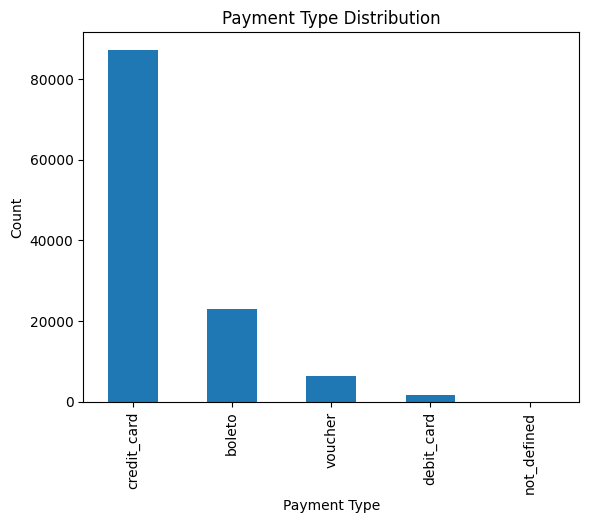

In [15]:
import matplotlib.pyplot as plt

payment_counts = merged_df["payment_type"].value_counts()

payment_counts.plot(kind="bar")

plt.title("Payment Type Distribution")
plt.xlabel("Payment Type")
plt.ylabel("Count")

plt.show()

In [16]:
merged_df.to_csv("../data/cleaned_ecommerce_data.csv", index=False)

In [17]:
monthly_sales = (
    merged_df
    .groupby("order_month")["payment_value"]
    .sum()
)

print(monthly_sales)

order_month
1     1604364.20
2     1660962.64
3     2024783.73
4     2008735.49
5     2242130.09
6     1907577.19
7     2104021.01
8     2124967.30
9     1027923.50
10    1108215.37
11    1599444.18
12    1057601.96
Name: payment_value, dtype: float64


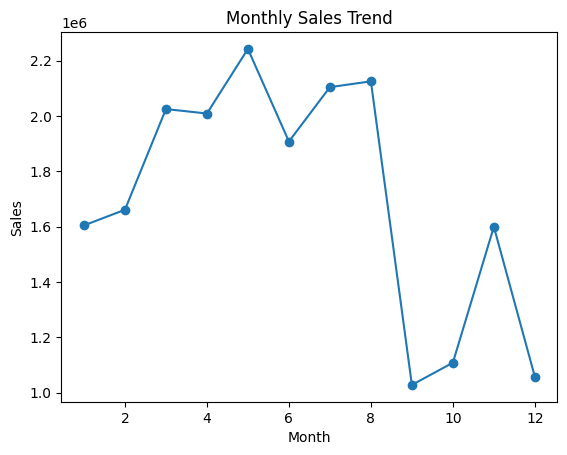

In [18]:
monthly_sales.plot(kind="line", marker="o")

import matplotlib.pyplot as plt

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

In [19]:
top_categories = (
    merged_df
    .groupby("product_category_name")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_categories)

product_category_name
cama_mesa_banho           1712553.67
beleza_saude              1657373.12
informatica_acessorios    1585330.45
moveis_decoracao          1430176.39
relogios_presentes        1429216.68
esporte_lazer             1392127.56
utilidades_domesticas     1094758.13
automotivo                 852294.33
ferramentas_jardim         838280.75
cool_stuff                 779698.00
Name: payment_value, dtype: float64


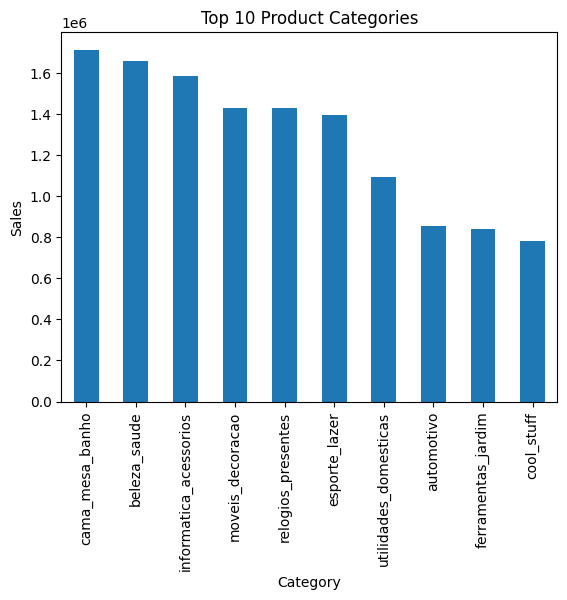

In [20]:
top_categories.plot(kind="bar")

plt.title("Top 10 Product Categories")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

In [21]:
top_states = (
    merged_df
    .groupby("customer_state")["payment_value"]
    .sum()
    .sort_values(ascending=False)
)

print(top_states.head(10))

customer_state
SP    7673188.55
RJ    2783724.26
MG    2341861.47
RS    1152019.17
PR    1074614.19
BA     802416.72
SC     799135.92
GO     516182.51
DF     434512.55
ES     406946.26
Name: payment_value, dtype: float64


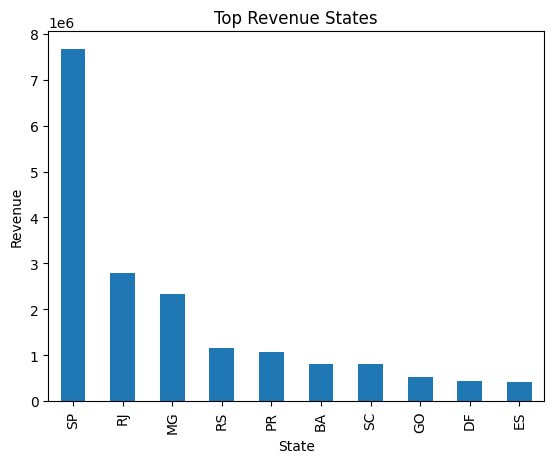

In [22]:
top_states.head(10).plot(kind="bar")

plt.title("Top Revenue States")
plt.xlabel("State")
plt.ylabel("Revenue")

plt.show()

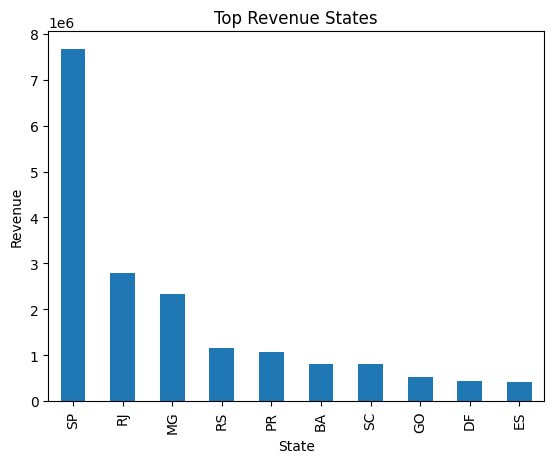

In [23]:
top_states.head(10).plot(kind="bar")

plt.title("Top Revenue States")
plt.xlabel("State")
plt.ylabel("Revenue")

plt.show()

In [24]:
aov = (
    merged_df["payment_value"].sum()
    /
    merged_df["order_id"].nunique()
)

print("Average Order Value:", round(aov, 2))

Average Order Value: 205.86


In [25]:
payment_analysis = (
    merged_df
    .groupby("payment_type")["payment_value"]
    .sum()
    .sort_values(ascending=False)
)

print(payment_analysis)

payment_type
credit_card    15694885.84
boleto          4086820.71
voucher          432602.19
debit_card       256417.92
not_defined           0.00
Name: payment_value, dtype: float64


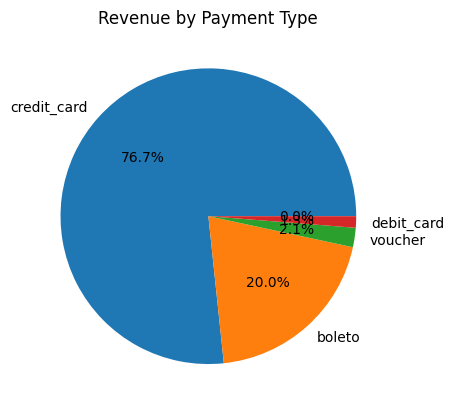

In [26]:
payment_analysis.plot(kind="pie", autopct="%1.1f%%")

plt.title("Revenue by Payment Type")
plt.ylabel("")

plt.show()

In [27]:
order_status = (
    merged_df["order_status"]
    .value_counts()
)

print(order_status)

order_status
delivered      115038
shipped          1245
canceled          745
unavailable       650
processing        375
invoiced          373
created             5
approved            3
Name: count, dtype: int64


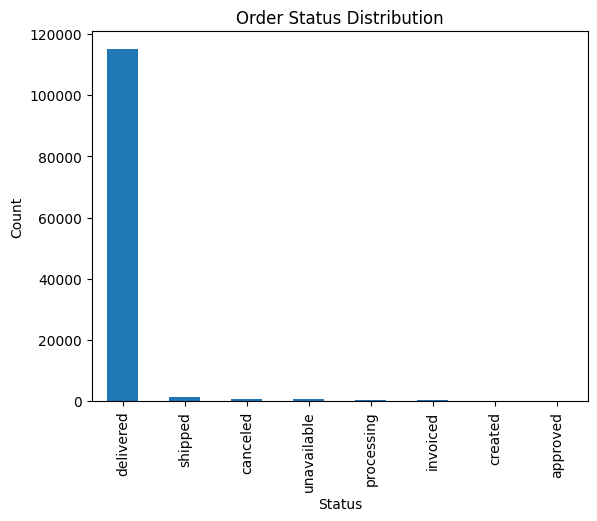

In [28]:
order_status.plot(kind="bar")

plt.title("Order Status Distribution")
plt.xlabel("Status")
plt.ylabel("Count")

plt.show()

In [29]:
final_df = merged_df[
    [
        "order_id",
        "customer_id",
        "order_status",
        "order_purchase_timestamp",
        "order_year",
        "order_month",
        "order_day",
        "customer_city",
        "customer_state",
        "payment_type",
        "payment_value",
        "product_id",
        "seller_id",
        "price",
        "freight_value",
        "product_category_name"
    ]
]

In [30]:
final_df.to_csv(
    "../data/final_ecommerce_data.csv",
    index=False
)